In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder 
import tensorflow 
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential

2026-03-23 08:55:27.318031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774256127.596397      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774256127.686750      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774256128.374159      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774256128.374203      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774256128.374207      17 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/car-evaluation-classification/cars.csv")
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
df.shape

(1728, 7)

In [4]:
df['buying'].value_counts()

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

In [5]:
df['maint'].value_counts()

maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

In [6]:
df['doors'].value_counts()

doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

In [7]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [8]:
df['lug_boot'].value_counts()

lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [10]:
x = df.drop(columns = ['class'], axis = 1)
y = df['class']

In [11]:
x

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


In [12]:
encode = LabelEncoder()
y= encode.fit_transform(y)
y

array([2, 2, 2, ..., 2, 1, 3])

In [13]:
for col in x.columns:
    x[col] = encode.fit_transform(x[col])

In [14]:
x

,buying,maint,doors,persons,lug_boot,safety
0,3,3,0,0,2,1
1,3,3,0,0,2,2
2,3,3,0,0,2,0
3,3,3,0,0,1,1
4,3,3,0,0,1,2
...,...,...,...,...,...,...
1723,1,1,3,2,1,2
1724,1,1,3,2,1,0
1725,1,1,3,2,0,1
1726,1,1,3,2,0,2


In [15]:
y

array([2, 2, 2, ..., 2, 1, 3])

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.20, random_state = 42, stratify= y)

In [17]:
scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.fit_transform(x_test)

In [18]:
x_train_scaler

array([[ 0.44471024,  0.46853425, -0.42542184, -0.02112909,  0.00798628,
         1.24832681],
       [ 0.44471024, -1.34269466, -0.42542184, -1.23781227,  1.23432408,
         1.24832681],
       [-0.43705383, -1.34269466,  1.35349793,  1.1955541 ,  1.23432408,
         1.24832681],
       ...,
       [-0.43705383,  1.37414871, -1.31488173, -1.23781227, -1.21835152,
        -1.20745632],
       [-0.43705383, -0.4370802 ,  0.46403805, -1.23781227,  0.00798628,
         1.24832681],
       [ 0.44471024, -0.4370802 ,  0.46403805, -0.02112909,  0.00798628,
         1.24832681]])

In [19]:
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

In [20]:
per = Perceptron(max_iter=2000, random_state = 42)
per.fit(x_train_scaler, y_train)

Perceptron(max_iter=2000, random_state=42)

In [21]:
y_pred_per = per.predict(x_test_scaler)
y_pred_per

array([0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0, 0, 2, 2, 0, 0,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2,
       0, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2,
       2, 0, 2, 1, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 1, 1, 0,
       0, 0, 2, 1, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2,
       0, 0, 2, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2,
       0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2,
       2, 2, 1, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 1, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0,
       2, 2, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0,

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
acc = accuracy_score(y_test, y_pred_per)
acc

0.638728323699422

In [24]:
cr = classification_report(y_test, y_pred_per)
print(cr)

              precision    recall  f1-score   support

           0       0.37      0.48      0.42        77
           1       0.00      0.00      0.00        14
           2       0.79      0.76      0.78       242
           3       0.00      0.00      0.00        13

    accuracy                           0.64       346
   macro avg       0.29      0.31      0.30       346
weighted avg       0.64      0.64      0.64       346



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
cf = confusion_matrix(y_test, y_pred_per)
print(cf)

[[ 37   5  35   0]
 [  7   0   7   0]
 [ 50   8 184   0]
 [  6   1   6   0]]


In [26]:
y_train_cat = to_categorical(y_train, num_classes = 4)
y_test_cat = to_categorical(y_test, num_classes = 4)
y_test_cat

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]])

In [27]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [28]:
model = Sequential([
    Dense(16,input_dim = 6,activation = 'relu'),
    Dense(12, activation = 'relu'),
    Dense(8,activation = 'relu'),
    Dense(4, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-23 08:55:56.788611: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [29]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [30]:
history = model.fit(
    x_train_scaler, y_train_cat,
    epochs = 100, batch_size = 12, validation_split = 0.2,  verbose = 1 
)

Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1230 - loss: 1.7653 - val_accuracy: 0.6498 - val_loss: 1.1767
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6991 - loss: 1.0859 - val_accuracy: 0.6823 - val_loss: 0.9478
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7003 - loss: 0.8842 - val_accuracy: 0.6823 - val_loss: 0.8482
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6994 - loss: 0.7937 - val_accuracy: 0.6823 - val_loss: 0.7861
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7027 - loss: 0.7072 - val_accuracy: 0.6823 - val_loss: 0.7341
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6806 - loss: 0.6862 - val_accuracy: 0.6823 - val_loss: 0.6849
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6837 - loss: 0.6466 - val_accuracy: 0.6859 - val_loss: 0.6406
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7486 - loss: 0.5291 - val_accuracy: 0.7509 - v

In [31]:
loss, acc = model.evaluate(x_test_scaler, y_test_cat, verbose = 1)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9596 - loss: 0.1171 


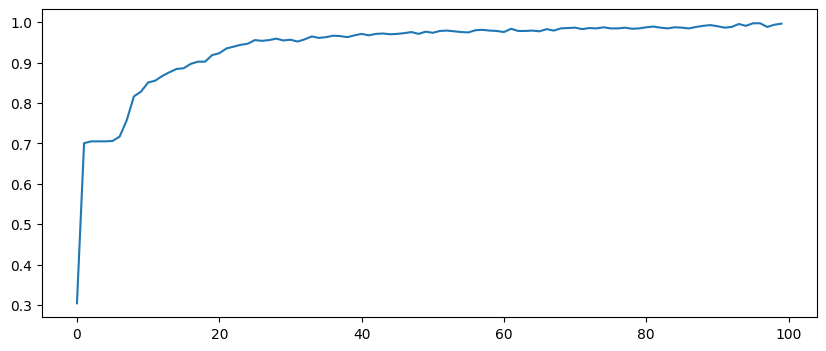

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,4) )
plt.plot(history.history['accuracy'], label = 'train')